## NVDA Time Series – Main Notebook

This notebook replaces the previous `main.py` script as the primary interactive entry point for the NVDA projects.

Use it to:
- Download and load the NVDA dataset.
- Run preprocessing and basic data description.
- Inspect the DataFrame with commands like `df.head()`.
- Later: perform transformations to returns and add visualizations (after we verify the time-series structure).


In [1]:
from data_loader import download_nvda_data, load_nvda_data
from preprocessing import preprocess_prices
from analysis import print_data_overview, print_descriptive_statistics

df = None  # will hold the processed NVDA DataFrame


In [2]:
# Step 1: download (or refresh) the NVDA dataset and save it as CSV.
download_nvda_data()

# Step 2: load the saved dataset from disk and preprocess prices.
df = load_nvda_data()
df = preprocess_prices(df)

print_data_overview(df)
print_descriptive_statistics(
    df,
    columns=["Open", "High", "Low", "Close", "Volume"],
    title="Price and volume descriptive statistics",
)


[*********************100%***********************]  1 of 1 completed

Downloaded 1297 rows for NVDA and saved to C:\Users\ass\Documents\NVDA\data\nvda_raw.csv
=== Data overview ===
Number of rows: 1297
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Date range: 2021-01-04 00:00:00 -> 2026-03-04 00:00:00

=== Price and volume descriptive statistics ===
              Open         High          Low        Close        Volume
count  1297.000000  1297.000000  1297.000000  1297.000000  1.297000e+03
mean     71.062795    72.241455    69.736683    71.038813  3.879523e+08
std      60.419920    61.230511    59.402573    60.325123  1.846455e+08
min      10.957224    11.720265    10.799422    11.212903  6.552850e+07
25%      19.641072    19.984306    19.207045    19.618124  2.313979e+08
50%      42.720443    43.583291    42.103367    42.965748  3.713890e+08
75%     123.746155   126.445877   120.978210   123.997536  5.011480e+08
max     208.068415   212.178195   205.548551   207.028473  1.543911e+09



In [3]:
# Inspect the first few rows to understand the structure.
df.head(15)


,Close,High,Low,Open,Volume
Date,,,,,
2021-01-04,13.076726,13.614215,12.926149,13.067502,560640000
2021-01-05,13.367161,13.405802,13.050302,13.063016,322760000
2021-01-06,12.579125,13.207857,12.550706,13.185420,580424000
2021-01-07,13.306579,13.340235,12.850362,12.931134,461480000
2021-01-08,13.239517,13.383363,13.005426,13.325027,292528000
2021-01-11,13.583302,13.921850,13.325028,13.381120,518344000
2021-01-12,13.446935,13.715929,13.307577,13.713934,291476000
2021-01-13,13.493802,13.586791,13.347464,13.452169,210028000
2021-01-14,13.163234,13.561613,13.143539,13.536933,283120000


In [4]:
from preprocessing import add_return_columns

# Transform Close prices into simple and log returns
# (Run this after the previous cells so that `df` is defined.)

df = add_return_columns(df, price_column="Close")

print_descriptive_statistics(
    df,
    columns=["Return_simple", "Return_log"],
    title="Return descriptive statistics",
)

df[["Close", "Return_simple", "Return_log"]].head()

=== Return descriptive statistics ===
       Return_simple   Return_log
count    1296.000000  1296.000000
mean        0.002565     0.002036
std         0.032633     0.032384
min        -0.169682    -0.185946
25%        -0.015890    -0.016018
50%         0.002904     0.002900
75%         0.020797     0.020584
max         0.243696     0.218088



,Close,Return_simple,Return_log
Date,,,
2021-01-04,13.076726,NaN,NaN
2021-01-05,13.367161,0.022210,0.021967
2021-01-06,12.579125,-0.058953,-0.060762
2021-01-07,13.306579,0.057830,0.056220
2021-01-08,13.239517,-0.005040,-0.005052


In [5]:
from analysis import extended_descriptive_table

# Extended statistics for prices and returns (mean, variance, std, range, IQR, skewness, kurtosis)
extended_descriptive_table(
    df,
    columns=["Close", "Return_simple", "Return_log"],
    title="Extended statistics for prices and returns",
)

=== Extended statistics for prices and returns ===
                       Close  Return_simple  Return_log
mean               71.038813       0.002565    0.002036
variance         3639.120497       0.001065    0.001049
std                60.325123       0.032633    0.032384
min                11.212903      -0.169682   -0.185946
max               207.028473       0.243696    0.218088
range             195.815570       0.413378    0.404034
Q1                 19.618124      -0.015890   -0.016018
median             42.965748       0.002904    0.002900
Q3                123.997536       0.020797    0.020584
IQR               104.379412       0.036687    0.036602
skewness            0.716438       0.512090    0.228584
kurtosis            2.008819       7.521640    6.677599
excess_kurtosis    -0.991181       4.521640    3.677599



,Close,Return_simple,Return_log
mean,71.038813,0.002565,0.002036
variance,3639.120497,0.001065,0.001049
std,60.325123,0.032633,0.032384
min,11.212903,-0.169682,-0.185946
max,207.028473,0.243696,0.218088
range,195.815570,0.413378,0.404034
Q1,19.618124,-0.015890,-0.016018
median,42.965748,0.002904,0.002900
Q3,123.997536,0.020797,0.020584
IQR,104.379412,0.036687,0.036602


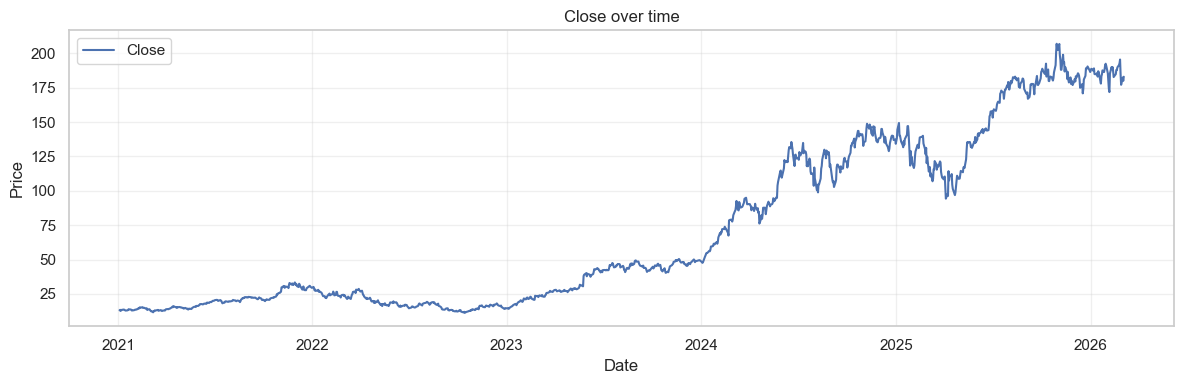

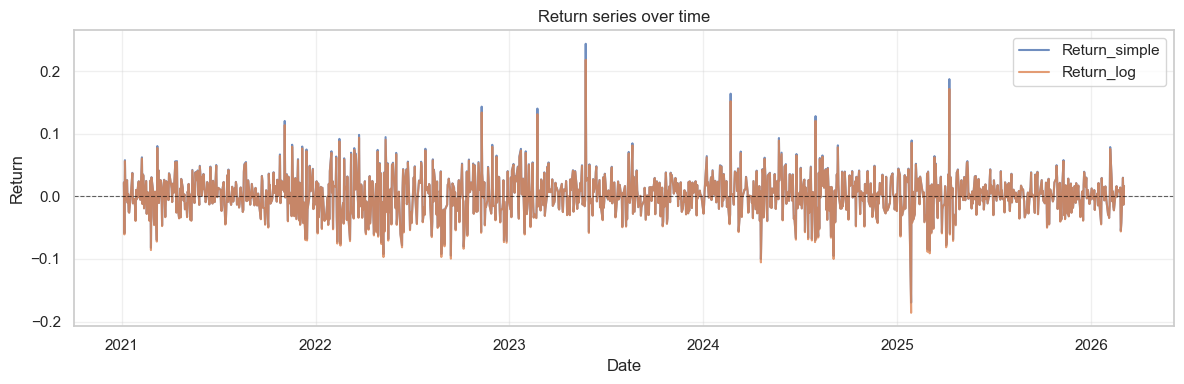

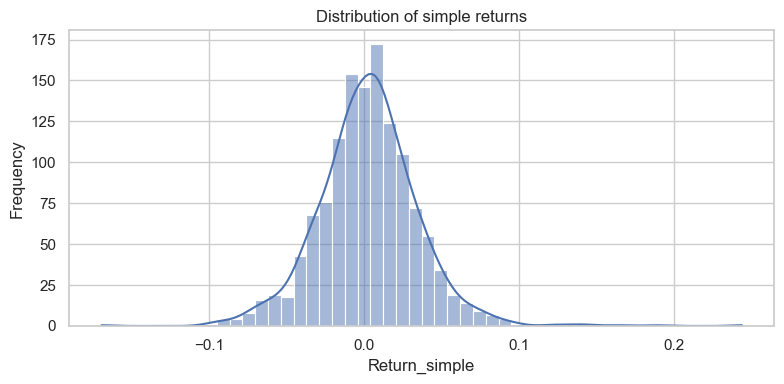

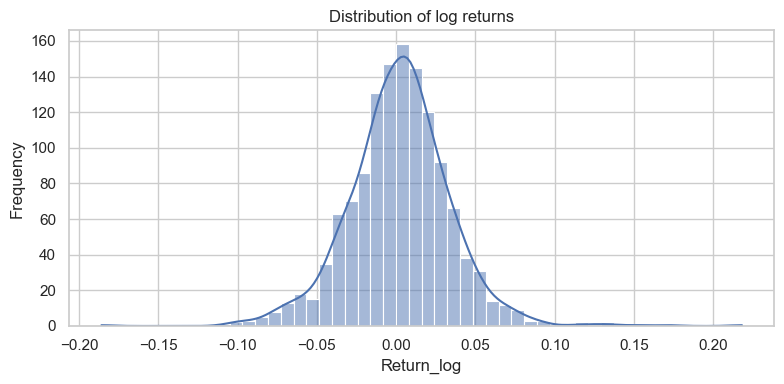

In [6]:
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingImports]
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]
from analysis import plot_price_series, plot_return_series, plot_distribution

sns.set(style="whitegrid")

# Time series plots
plot_price_series(df, price_column="Close")
plot_return_series(df, columns=["Return_simple", "Return_log"])

# Distribution plots for returns
plot_distribution(df, column="Return_simple", title="Distribution of simple returns")
plot_distribution(df, column="Return_log", title="Distribution of log returns")